# LambdaRank on MSLR 10k
### Learning to Rank — Lambda Gradient Approach
---
**Dataset**: MSLR 10K  
**Model**: ScoringMLP(MLP) trained with LambdaRank lambda gradients   
**Gradients**: Lambda(λ)  
**Metrics**: NDCG@K

## Project Overview

This notebook implements **LambdaRank**. Note: The underlying neural network is
exactly the same as the Pointwise and RankNet notebooks. The only thing that changes
here is how we calculate the error using Lambda gradients.

Instead of defining a scalar loss function and differentiating it, LambdaRank
directly injects gradient signals (λ values) into the network's backward pass.
Each λ_i encodes both the **direction** (should the score go up or down?) and
**magnitude** (by how much, weighted by NDCG impact?) of the update.

### What this notebook covers

| Step | Description |
|------|-------------|
| 1–2  | Environment setup and dataset extraction |
| 3    | Data loading via `ltr.data.load_fold` |
| 4    | Model definition using `ltr.models.ScoringMLP` |
| 5    | How Lambda gradients are computed |
| 6    | Training with different architectures and dropouts |
| 7    | Multiseed evaluation to choose the best model |
| 8    | 5-Fold Evaluation (Standard MSLR Folds) |
| 9    | Ablation study across linear and deep architectures |


## Step 1 · Colab Setup & Package Installation

In [1]:
# ── Colab Setup ───────────────────────────────────────────────────────────────
# This cell clones the repo (if needed) and installs the ltr package.
# Change REPO_PATH if you cloned to a different location.
import os, subprocess, sys

REPO_PATH = "/content/Learning-To-Rank-for-Search"

if not os.path.exists(REPO_PATH):
    subprocess.run(
        ["git", "clone",
         "https://github.com/navaneeswar854/Learning-To-Rank-for-Search.git",
         REPO_PATH],
        check=True,
    )
    print("Repo cloned.")
else:
    print("Repo already present.")

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-e", REPO_PATH + "/Phase2_3_Learning_to_Rank", "-q"],
    check=True,
)
print("ltr package installed.")

# Add to sys.path so the kernel finds it immediately without restarting
sys.path.insert(0, REPO_PATH + "/Phase2_3_Learning_to_Rank")


Repo cloned.
ltr package installed.


## Step 2 · Dataset Extraction

In [2]:
import gdown
drive_url = "https://drive.google.com/file/d/105jdh6AV47C0PDt7RzLZF1-u7m9Tk1oY/view?usp=drive_link"
# Download the file
gdown.download(drive_url, output="mslr.zip", fuzzy=True)

Downloading...
From (original): https://drive.google.com/uc?id=105jdh6AV47C0PDt7RzLZF1-u7m9Tk1oY
From (redirected): https://drive.google.com/uc?id=105jdh6AV47C0PDt7RzLZF1-u7m9Tk1oY&confirm=t&uuid=7dad4058-234e-4fea-8130-140971199eab
To: /content/mslr.zip
100%|██████████| 1.45G/1.45G [00:26<00:00, 55.0MB/s]


'mslr.zip'

In [3]:
# ── Extract MSLR 10k dataset ────────────────────────────────────────────────────
import zipfile, os

ZIP_PATH  = "/content/mslr.zip"
DATA_PATH = "/content/MSLR"

if not os.path.exists(DATA_PATH):
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall("/content/")
    print("Dataset extracted.")
else:
    print("Dataset already extracted.")


Dataset extracted.


## Step 3 · Imports & Configuration

In [4]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# ── ltr package ───────────────────────────────────────────────────────────────
from ltr.data_mslr     import load_fold
from ltr.models   import ScoringMLP
from ltr.train    import train, train_multiseed, set_seed
from ltr.metrics  import mean_ndcg, per_query_ndcg, paired_significance
from ltr.evaluate import cross_fold_eval

# ── Global config ─────────────────────────────────────────────────────────────
DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_PATH = "/content"
SEEDS     = (42, 123, 456)
K_LIST    = (1, 3, 5, 10)

print(f"Device  : {DEVICE}")
print(f"PyTorch : {torch.__version__}")

Device  : cuda
PyTorch : 2.11.0+cu128


## Step 4 · Data Loading

In [17]:
train_loader, val_loader, test_loader = load_fold(
    base_path=DATA_PATH, fold_num=1, batch_size=4
)

sample_qids, sample_feats, sample_labels = next(iter(train_loader))
print(f"Batch: {len(sample_qids)} queries")
print(f"Query 0 features shape: {sample_feats[0].shape}")
print(f"Query 0 labels        : {sample_labels[0].tolist()}")


  [Fold 1] Loading train split...


  [Fold 1] Loading val split...


  [Fold 1] Loading test split...


  Fold 1: 6000 train | 2000 val | 2000 test queries
  Features: 111 (136 total − 25 dropped)
  Normalization: Per-query z-score
Batch: 4 queries
Query 0 features shape: torch.Size([124, 111])
Query 0 labels        : [0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 2.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 2.0, 1.0, 1.0, 2.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 4.0, 0.0, 2.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 2.0, 3.0, 0.0, 0.0, 1.0, 0.0, 2.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 2.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


## Step 5 · How Lambda Gradients Work

For every valid pair $(i, j)$ where document $i$ is more relevant than $j$:

$$\lambda_{ij} = \sigma(-(s_i - s_j)) \cdot |\Delta\text{NDCG}_{ij}|$$

The net lambda for each document accumulates over all its pairs:

$$\lambda_i = -\sum_{j:\,rel_i > rel_j} \lambda_{ij} \quad+\quad \sum_{j:\,rel_j > rel_i} \lambda_{ij}$$

A **negative** $\lambda_i$ means "push this document's score up";
a **positive** $\lambda_i$ means "push it down".


## Step 6 · Training (Single Fold, Baseline Run)

LambdaRank injects gradients directly via `scores.backward(lambdas)` — there is no scalar loss.

In [22]:
import matplotlib.pyplot as plt
import numpy as np

def plot_training_curves(train_ndcgs, val_ndcgs, title="Training Curves"):
    fig, ax = plt.subplots(figsize=(10, 5))

    # Find the best epoch
    best_epoch = np.argmax(val_ndcgs) + 1

    # Vertical dotted line for the best epoch
    ax.axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.8,
               label=f'Best Epoch ({best_epoch})')

    # Plot both curves on the same Y-axis
    ax.plot(range(1, len(train_ndcgs) + 1), train_ndcgs,
            label='Train NDCG@10', color='tab:red', marker='o')
    ax.plot(range(1, len(val_ndcgs) + 1), val_ndcgs,
            label='Val NDCG@10', color='tab:blue', marker='s')

    ax.set_xlabel('Epochs')
    ax.set_ylabel('NDCG@10')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

## Current Architecture:  111 -> 128 -> 64 -> 1

# No Regularization(Baseline)

In [ ]:
set_seed(42)
model = ScoringMLP(input_dim=111, hidden_dims=[128, 64], dropout=0.0).to(DEVICE)

best_model, last_model, train_ndcg_history, val_ndcg_history = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    mode="lambdarank",
    epochs=50,
    lr=0.001,
    k=10,
    patience=10,
    device=DEVICE,
    verbose=True,
)


Epoch 01/50 | Avg λ Norm: 4.9775 | Train NDCG@10: 0.4199 | Val NDCG@10: 0.4203  ← best
Epoch 02/50 | Avg λ Norm: 4.7613 | Train NDCG@10: 0.4222 | Val NDCG@10: 0.4236  ← best
Epoch 03/50 | Avg λ Norm: 4.7090 | Train NDCG@10: 0.4280 | Val NDCG@10: 0.4293  ← best
Epoch 04/50 | Avg λ Norm: 4.6278 | Train NDCG@10: 0.4308 | Val NDCG@10: 0.4325  ← best
Epoch 05/50 | Avg λ Norm: 4.5963 | Train NDCG@10: 0.4302 | Val NDCG@10: 0.4310
Epoch 06/50 | Avg λ Norm: 4.5458 | Train NDCG@10: 0.4360 | Val NDCG@10: 0.4342  ← best
Epoch 07/50 | Avg λ Norm: 4.5199 | Train NDCG@10: 0.4310 | Val NDCG@10: 0.4306
Epoch 08/50 | Avg λ Norm: 4.4833 | Train NDCG@10: 0.4323 | Val NDCG@10: 0.4302
Epoch 09/50 | Avg λ Norm: 4.4458 | Train NDCG@10: 0.4419 | Val NDCG@10: 0.4388  ← best
Epoch 10/50 | Avg λ Norm: 4.4267 | Train NDCG@10: 0.4384 | Val NDCG@10: 0.4329
Epoch 11/50 | Avg λ Norm: 4.4152 | Train NDCG@10: 0.4360 | Val NDCG@10: 0.4304
Epoch 12/50 | Avg λ Norm: 4.3928 | Train NDCG@10: 0.4452 | Val NDCG@10: 0.4374
Epoc

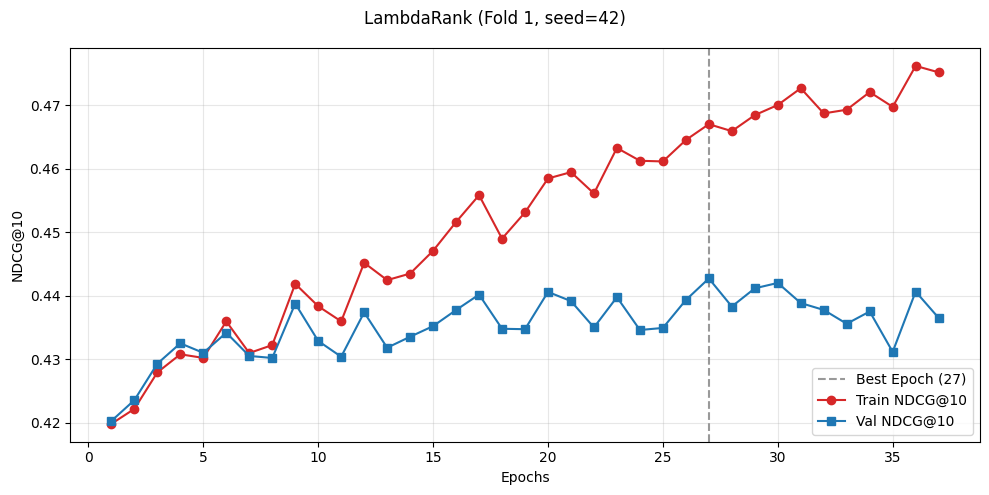

In [ ]:
plot_training_curves(train_ndcg_history,val_ndcg_history, "LambdaRank (Fold 1, seed=42)")


## Key Takeaways:

- Till Epoch 10, The Validation NDCG moved along with Training NDCG. From 10, The Training NDCG keeps on increasing, but the validation NDCG degrades. At Epoch 27, we got a slightly better result.
- After 27, The Val NDCG reached the lowest score with **0.4312**.
- But it also not decreasing. However, **"train keeps improving while val stops improving, and a gap opens between them that doesn't close** is considered overfitting.

## Next Steps:
- Use weight decay and see if there is any training noise that is causing overfitting.

## Results on Test Data

In [ ]:
test_ndcg = mean_ndcg(best_model, test_loader, k_list=K_LIST, device=DEVICE)

print("\nTest Set NDCG — Fold 1 (No Regularization, seed=42)")
print(f"{'─'*30}")
for k in K_LIST:
    print(f"  NDCG@{k:<3}: {test_ndcg[k]:.4f}")



Test Set NDCG — Fold 1 (No Regularization, seed=42)
──────────────────────────────
  NDCG@1  : 0.4181
  NDCG@3  : 0.4089
  NDCG@5  : 0.4117
  NDCG@10 : 0.4322


- The Result is better than both the RankNet and Pointwise approaches

# Weight Decay

In [ ]:
set_seed(42)
model = ScoringMLP(input_dim=111, hidden_dims=[128, 64], dropout=0.0).to(DEVICE)

best_model, last_model, train_ndcg_history, val_ndcg_history = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    mode="lambdarank",
    epochs=50,
    lr=0.001,
    k=10,
    weight_decay = 1e-4,
    patience=10,
    device=DEVICE,
    verbose=True,
)

Epoch 01/50 | Avg λ Norm: 4.9869 | Train NDCG@10: 0.4188 | Val NDCG@10: 0.4224  ← best
Epoch 02/50 | Avg λ Norm: 4.7637 | Train NDCG@10: 0.4222 | Val NDCG@10: 0.4222
Epoch 03/50 | Avg λ Norm: 4.6812 | Train NDCG@10: 0.4286 | Val NDCG@10: 0.4289  ← best
Epoch 04/50 | Avg λ Norm: 4.6246 | Train NDCG@10: 0.4308 | Val NDCG@10: 0.4318  ← best
Epoch 05/50 | Avg λ Norm: 4.5948 | Train NDCG@10: 0.4275 | Val NDCG@10: 0.4286
Epoch 06/50 | Avg λ Norm: 4.5599 | Train NDCG@10: 0.4351 | Val NDCG@10: 0.4327  ← best
Epoch 07/50 | Avg λ Norm: 4.5339 | Train NDCG@10: 0.4337 | Val NDCG@10: 0.4315
Epoch 08/50 | Avg λ Norm: 4.4842 | Train NDCG@10: 0.4307 | Val NDCG@10: 0.4301
Epoch 09/50 | Avg λ Norm: 4.4667 | Train NDCG@10: 0.4414 | Val NDCG@10: 0.4371  ← best
Epoch 10/50 | Avg λ Norm: 4.4342 | Train NDCG@10: 0.4396 | Val NDCG@10: 0.4354
Epoch 11/50 | Avg λ Norm: 4.4377 | Train NDCG@10: 0.4412 | Val NDCG@10: 0.4350
Epoch 12/50 | Avg λ Norm: 4.4029 | Train NDCG@10: 0.4459 | Val NDCG@10: 0.4400  ← best
Epoc

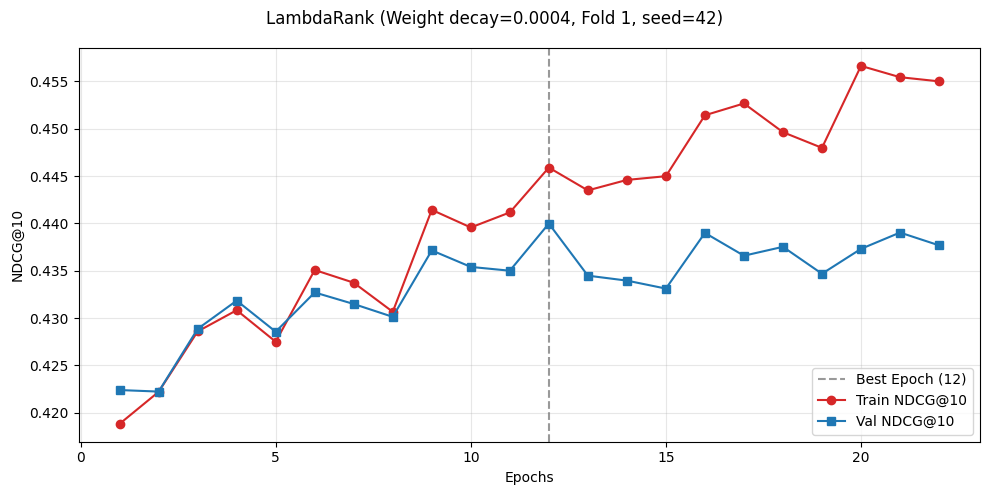

In [ ]:
plot_training_curves(train_ndcg_history,val_ndcg_history, "LambdaRank (Weight decay=0.0004, Fold 1, seed=42)")


## Key Takeaways:
- Faster Convergence - Since we are adding a decay to the gradient, the parameter takes a bigger step and training becomes faster.
- Same result as Baseline - There is no training noise in the data that might cause overfitting. Therefore, performed same as baseline(**Best Val = 0.443**).

## Next Steps:
- I will use dropout regularization and check if it helps in regularization.

## Results on Test Data

In [ ]:
test_ndcg = mean_ndcg(best_model, test_loader, k_list=K_LIST, device=DEVICE)

print("\nTest Set NDCG — Fold 1 (No Regularization, seed=42)")
print(f"{'─'*30}")
for k in K_LIST:
    print(f"  NDCG@{k:<3}: {test_ndcg[k]:.4f}")


Test Set NDCG — Fold 1 (No Regularization, seed=42)
──────────────────────────────
  NDCG@1  : 0.4089
  NDCG@3  : 0.4029
  NDCG@5  : 0.4096
  NDCG@10 : 0.4289


## Key Takeaways:
- The result is a bit worse than baseline. I will do a multiseed evaluation to check whether it is performing worse always.


## Using Dropout Regularization(0.2)

In [ ]:
set_seed(42)
model = ScoringMLP(input_dim=111, hidden_dims=[128, 64], dropout=0.2).to(DEVICE)

best_model, last_model, train_ndcg_history, val_ndcg_history = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    mode="lambdarank",
    epochs=50,
    lr=0.001,
    k=10,
    patience=10,
    device=DEVICE,
    verbose=True,
)

Epoch 01/50 | Avg λ Norm: 5.0759 | Train NDCG@10: 0.4188 | Val NDCG@10: 0.4208  ← best
Epoch 02/50 | Avg λ Norm: 4.8930 | Train NDCG@10: 0.4152 | Val NDCG@10: 0.4178
Epoch 03/50 | Avg λ Norm: 4.8478 | Train NDCG@10: 0.4161 | Val NDCG@10: 0.4181
Epoch 04/50 | Avg λ Norm: 4.7984 | Train NDCG@10: 0.4258 | Val NDCG@10: 0.4252  ← best
Epoch 05/50 | Avg λ Norm: 4.7905 | Train NDCG@10: 0.4241 | Val NDCG@10: 0.4244
Epoch 06/50 | Avg λ Norm: 4.7343 | Train NDCG@10: 0.4294 | Val NDCG@10: 0.4316  ← best
Epoch 07/50 | Avg λ Norm: 4.7207 | Train NDCG@10: 0.4287 | Val NDCG@10: 0.4281
Epoch 08/50 | Avg λ Norm: 4.6869 | Train NDCG@10: 0.4288 | Val NDCG@10: 0.4285
Epoch 09/50 | Avg λ Norm: 4.6939 | Train NDCG@10: 0.4348 | Val NDCG@10: 0.4325  ← best
Epoch 10/50 | Avg λ Norm: 4.6720 | Train NDCG@10: 0.4359 | Val NDCG@10: 0.4339  ← best
Epoch 11/50 | Avg λ Norm: 4.6489 | Train NDCG@10: 0.4361 | Val NDCG@10: 0.4323
Epoch 12/50 | Avg λ Norm: 4.6256 | Train NDCG@10: 0.4364 | Val NDCG@10: 0.4357  ← best
Epoc

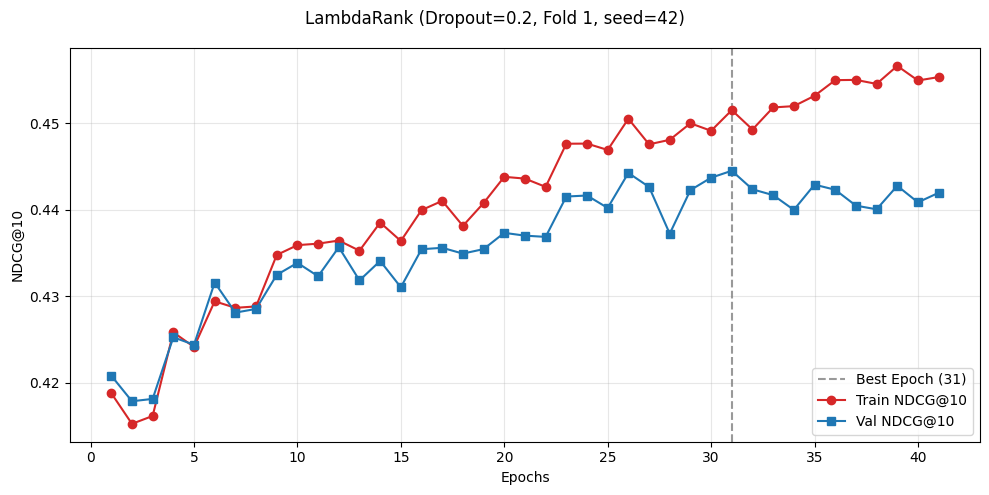

In [ ]:
plot_training_curves(train_ndcg_history,val_ndcg_history, "LambdaRank (Dropout=0.2, Fold 1, seed=42)")

## Key Takeaways:
- The best validation NDCG (**0.443->0.444**).
- The difference is minimal but in Baseline Val NDCG degraded to **0.4312**. Here, The val NDCG is flat oscillating between **0.44-0.444**.
- The Dropout regularization is helping.
- The convergence is very slow.

## Next Steps:
- Increase Dropout and see if it helps in regularizing more.
- Use weight decay to make the training faster.

## Results on Test Data

In [ ]:
test_ndcg = mean_ndcg(best_model, test_loader, k_list=K_LIST, device=DEVICE)

print("\nTest Set NDCG — Fold 1 (seed=42)")
print(f"{'─'*30}")
for k in K_LIST:
    print(f"  NDCG@{k:<3}: {test_ndcg[k]:.4f}")



Test Set NDCG — Fold 1 (seed=42)
──────────────────────────────
  NDCG@1  : 0.4188
  NDCG@3  : 0.4050
  NDCG@5  : 0.4114
  NDCG@10 : 0.4312



Test Set NDCG — Fold 1 (No Regularization, seed=42)
──────────────────────────────    
  NDCG@1  : 0.4181   
  NDCG@3  : 0.4089   
  NDCG@5  : 0.4117   
  NDCG@10 : 0.4322  
## Key Takeaways:
- The difference is too small. So, we cannot say if dropout is helping or not.
- But we saw that dropout is helping a bit during the training.

## Next Steps:
- I will increase dropout and observe the results.

## Increasing Dropout(0.3)

In [ ]:
set_seed(42)
model = ScoringMLP(input_dim=111, hidden_dims=[128, 64], dropout=0.3).to(DEVICE)

best_model, last_model, train_ndcg_history, val_ndcg_history = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    mode="lambdarank",
    epochs=50,
    lr=0.001,
    k=10,
    weight_decay = 1e-4,
    patience=10,
    device=DEVICE,
    verbose=True,
)

Epoch 01/50 | Avg λ Norm: 5.1428 | Train NDCG@10: 0.4119 | Val NDCG@10: 0.4119  ← best
Epoch 02/50 | Avg λ Norm: 4.9756 | Train NDCG@10: 0.4128 | Val NDCG@10: 0.4167  ← best
Epoch 03/50 | Avg λ Norm: 4.9290 | Train NDCG@10: 0.4179 | Val NDCG@10: 0.4191  ← best
Epoch 04/50 | Avg λ Norm: 4.8904 | Train NDCG@10: 0.4225 | Val NDCG@10: 0.4254  ← best
Epoch 05/50 | Avg λ Norm: 4.8437 | Train NDCG@10: 0.4209 | Val NDCG@10: 0.4195
Epoch 06/50 | Avg λ Norm: 4.8314 | Train NDCG@10: 0.4274 | Val NDCG@10: 0.4288  ← best
Epoch 07/50 | Avg λ Norm: 4.7695 | Train NDCG@10: 0.4232 | Val NDCG@10: 0.4254
Epoch 08/50 | Avg λ Norm: 4.7780 | Train NDCG@10: 0.4258 | Val NDCG@10: 0.4270
Epoch 09/50 | Avg λ Norm: 4.7586 | Train NDCG@10: 0.4322 | Val NDCG@10: 0.4306  ← best
Epoch 10/50 | Avg λ Norm: 4.7430 | Train NDCG@10: 0.4289 | Val NDCG@10: 0.4288
Epoch 11/50 | Avg λ Norm: 4.7367 | Train NDCG@10: 0.4292 | Val NDCG@10: 0.4270
Epoch 12/50 | Avg λ Norm: 4.7223 | Train NDCG@10: 0.4332 | Val NDCG@10: 0.4332  ← b

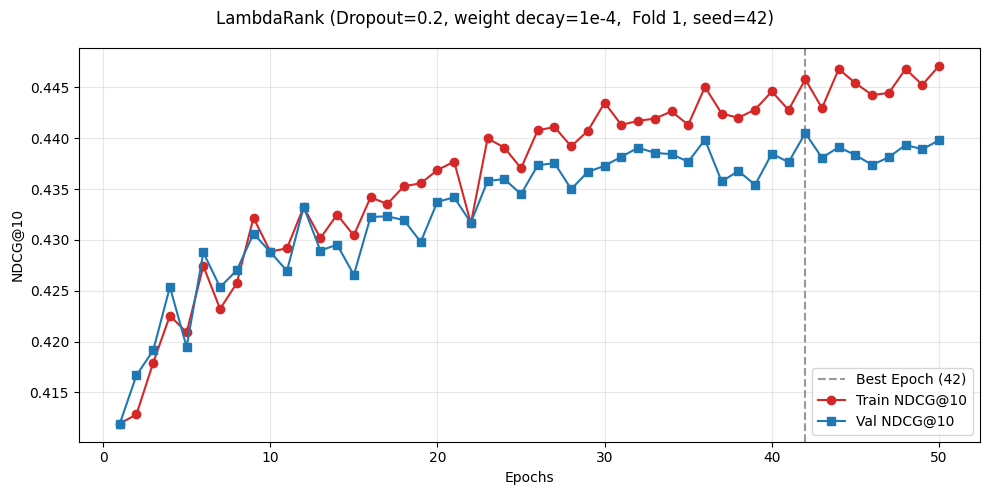

In [ ]:
plot_training_curves(train_ndcg_history,val_ndcg_history, "LambdaRank (Dropout=0.2, weight decay=1e-4,  Fold 1, seed=42)")

## Key Takeaways:
- The training and val curves are continuously increasing closely.
- The patience level is not yet met.I will train it for further 30 epochs.

In [ ]:
set_seed(42)
model = ScoringMLP(input_dim=111, hidden_dims=[128, 64], dropout=0.3).to(DEVICE)

best_model, last_model, train_ndcg_history, val_ndcg_history = train(
    model=last_model,
    train_loader=train_loader,
    val_loader=val_loader,
    mode="lambdarank",
    epochs=30,
    lr=0.001,
    k=10,
    weight_decay = 1e-4,
    patience=10,
    device=DEVICE,
    verbose=True,
)

Epoch 01/30 | Avg λ Norm: 4.5406 | Train NDCG@10: 0.4490 | Val NDCG@10: 0.4411  ← best
Epoch 02/30 | Avg λ Norm: 4.5040 | Train NDCG@10: 0.4446 | Val NDCG@10: 0.4389
Epoch 03/30 | Avg λ Norm: 4.5271 | Train NDCG@10: 0.4460 | Val NDCG@10: 0.4363
Epoch 04/30 | Avg λ Norm: 4.5502 | Train NDCG@10: 0.4479 | Val NDCG@10: 0.4384
Epoch 05/30 | Avg λ Norm: 4.5173 | Train NDCG@10: 0.4494 | Val NDCG@10: 0.4401
Epoch 06/30 | Avg λ Norm: 4.5227 | Train NDCG@10: 0.4500 | Val NDCG@10: 0.4415  ← best
Epoch 07/30 | Avg λ Norm: 4.5252 | Train NDCG@10: 0.4507 | Val NDCG@10: 0.4394
Epoch 08/30 | Avg λ Norm: 4.5112 | Train NDCG@10: 0.4484 | Val NDCG@10: 0.4359
Epoch 09/30 | Avg λ Norm: 4.5140 | Train NDCG@10: 0.4488 | Val NDCG@10: 0.4396
Epoch 10/30 | Avg λ Norm: 4.4931 | Train NDCG@10: 0.4482 | Val NDCG@10: 0.4373
Epoch 11/30 | Avg λ Norm: 4.5321 | Train NDCG@10: 0.4486 | Val NDCG@10: 0.4339
Epoch 12/30 | Avg λ Norm: 4.5085 | Train NDCG@10: 0.4524 | Val NDCG@10: 0.4414
Epoch 13/30 | Avg λ Norm: 4.5132 | T

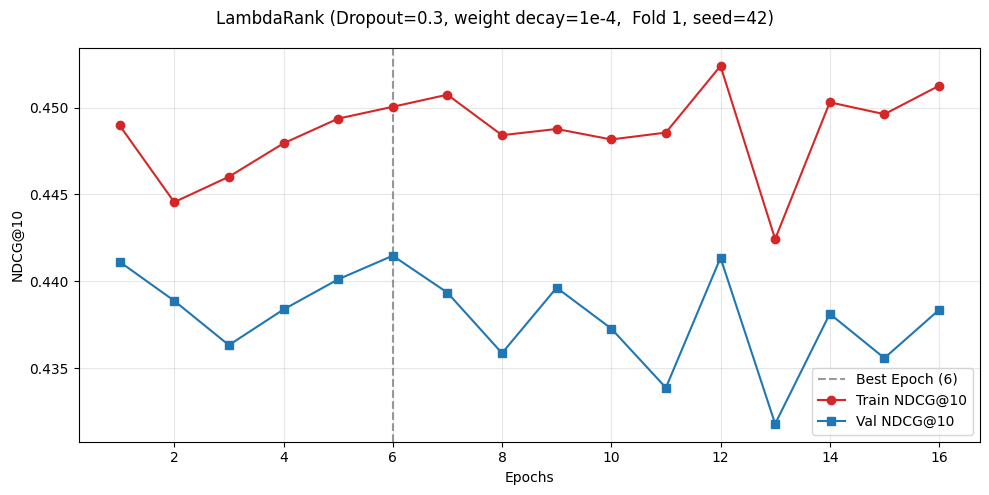

In [ ]:
plot_training_curves(train_ndcg_history,val_ndcg_history, "LambdaRank (Dropout=0.3, weight decay=1e-4,  Fold 1, seed=42)")

## Key Takeaways:
- Both training and validation curves flattened out but the best validation NDCG we got is 0.4415
- Still baseline is better than the regularized model.

## Results on Test Data

In [ ]:
test_ndcg = mean_ndcg(best_model, test_loader, k_list=K_LIST, device=DEVICE)

print("\nTest Set NDCG — Fold 1 (seed=42)")
print(f"{'─'*30}")
for k in K_LIST:
    print(f"  NDCG@{k:<3}: {test_ndcg[k]:.4f}")



Test Set NDCG — Fold 1 (seed=42)
──────────────────────────────
  NDCG@1  : 0.4057
  NDCG@3  : 0.4046
  NDCG@5  : 0.4093
  NDCG@10 : 0.4288


Test Set NDCG — Fold 1 (No Regularization, seed=42)     ──────────────────────────────  
NDCG@1 : 0.4181  
NDCG@3 : 0.4089  
NDCG@5 : 0.4117  
NDCG@10 : 0.4322   
## Key Takeaways:
- The results are not better in Test data also. Regularization is not helping.

# **Important Findings**:

1. Till now i have used normalization over the whole dataset. But this is a major mistake. We should use Per-Query Normalization in LETOR datasets.**The reason** - Global normalization compares documents across different queries, but NDCG only compares documents within the same query.
2. We are adding weight decay to the gradient and using adam as optimizer. Adam modifies the gradient based the variance and momentum. Changing the gradient also changes weight decay. This is not good, different weight are getting different decays in each step. So, I will use **Adamw** it separates gradient and weight and decay and only modifies gradient.

## Used Per-Query Normalization and Adaw

In [ ]:
set_seed(42)
model = ScoringMLP(input_dim=111, hidden_dims=[128, 64], dropout=0.3).to(DEVICE)

best_model, last_model, train_ndcg_history, val_ndcg_history = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    mode="lambdarank",
    epochs=80,
    lr=0.001,
    k=10,
    weight_decay = 1e-4,
    patience=10,
    device=DEVICE,
    verbose=True,
)

Epoch 01/80 | Avg λ Norm: 4.6300 | Train NDCG@10: 0.4318 | Val NDCG@10: 0.4323  ← best
Epoch 02/80 | Avg λ Norm: 4.4949 | Train NDCG@10: 0.4391 | Val NDCG@10: 0.4390  ← best
Epoch 03/80 | Avg λ Norm: 4.4520 | Train NDCG@10: 0.4372 | Val NDCG@10: 0.4356
Epoch 04/80 | Avg λ Norm: 4.4070 | Train NDCG@10: 0.4427 | Val NDCG@10: 0.4434  ← best
Epoch 05/80 | Avg λ Norm: 4.3966 | Train NDCG@10: 0.4484 | Val NDCG@10: 0.4482  ← best
Epoch 06/80 | Avg λ Norm: 4.3888 | Train NDCG@10: 0.4445 | Val NDCG@10: 0.4410
Epoch 07/80 | Avg λ Norm: 4.3532 | Train NDCG@10: 0.4490 | Val NDCG@10: 0.4476
Epoch 08/80 | Avg λ Norm: 4.3522 | Train NDCG@10: 0.4484 | Val NDCG@10: 0.4430
Epoch 09/80 | Avg λ Norm: 4.3254 | Train NDCG@10: 0.4507 | Val NDCG@10: 0.4472
Epoch 10/80 | Avg λ Norm: 4.3378 | Train NDCG@10: 0.4509 | Val NDCG@10: 0.4479
Epoch 11/80 | Avg λ Norm: 4.3403 | Train NDCG@10: 0.4513 | Val NDCG@10: 0.4457
Epoch 12/80 | Avg λ Norm: 4.3064 | Train NDCG@10: 0.4536 | Val NDCG@10: 0.4495  ← best
Epoch 13/80 

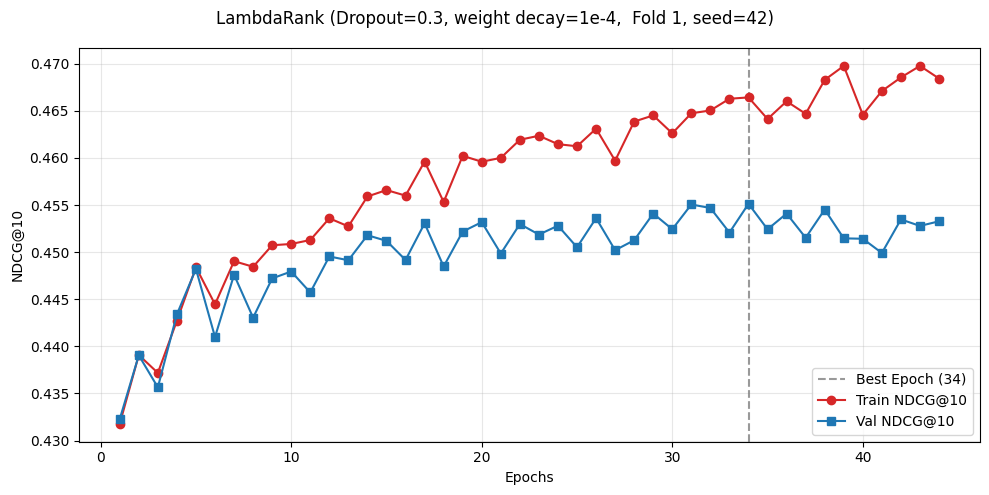

In [ ]:
plot_training_curves(train_ndcg_history,val_ndcg_history, "LambdaRank (Dropout=0.3, weight decay=1e-4,  Fold 1, seed=42)")

## Key Takeaways:
- The best val till now is **0.445**. But now we got **0.455**, this is a considerable improvement we got.
- So, Per-query normalization and Adamw are definitely helping.
- But I see a bit of gap between the training curve and val curve.I will try increasing dropout.

## Results on Test Data

In [ ]:
test_ndcg = mean_ndcg(best_model, test_loader, k_list=K_LIST, device=DEVICE)

print("\nTest Set NDCG — Fold 1 (dropout = 0.3, seed=42)")
print(f"{'─'*30}")
for k in K_LIST:
    print(f"  NDCG@{k:<3}: {test_ndcg[k]:.4f}")



Test Set NDCG — Fold 1 (dropout = 0.3, seed=42)
──────────────────────────────
  NDCG@1  : 0.4436
  NDCG@3  : 0.4253
  NDCG@5  : 0.4315
  NDCG@10 : 0.4478


## Key Takeaways:
- This is the highest score we got till now in test data. And NDCG@1 has a very big improvement (from **0.415->0.444**).
- We can see that NDCG@1> @3, @5. This is because lambdarank directly optimizes NDCG and placing the right doc at 1 will have bigger difference in NDCG so, lambdarank gives more preference for @1.

## Increasing Dropout(0.4)

In [ ]:
set_seed(42)
model = ScoringMLP(input_dim=111, hidden_dims=[128, 64], dropout=0.4).to(DEVICE)

best_model, last_model, train_ndcg_history, val_ndcg_history = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    mode="lambdarank",
    epochs=80,
    lr=0.001,
    k=10,
    weight_decay = 1e-4,
    patience=10,
    device=DEVICE,
    verbose=True,
)

Epoch 01/80 | Avg λ Norm: 4.6831 | Train NDCG@10: 0.4311 | Val NDCG@10: 0.4307  ← best
Epoch 02/80 | Avg λ Norm: 4.5506 | Train NDCG@10: 0.4360 | Val NDCG@10: 0.4373  ← best
Epoch 03/80 | Avg λ Norm: 4.4758 | Train NDCG@10: 0.4389 | Val NDCG@10: 0.4377  ← best
Epoch 04/80 | Avg λ Norm: 4.4884 | Train NDCG@10: 0.4405 | Val NDCG@10: 0.4413  ← best
Epoch 05/80 | Avg λ Norm: 4.4761 | Train NDCG@10: 0.4395 | Val NDCG@10: 0.4401
Epoch 06/80 | Avg λ Norm: 4.4296 | Train NDCG@10: 0.4429 | Val NDCG@10: 0.4418  ← best
Epoch 07/80 | Avg λ Norm: 4.4088 | Train NDCG@10: 0.4463 | Val NDCG@10: 0.4444  ← best
Epoch 08/80 | Avg λ Norm: 4.4308 | Train NDCG@10: 0.4469 | Val NDCG@10: 0.4467  ← best
Epoch 09/80 | Avg λ Norm: 4.4195 | Train NDCG@10: 0.4473 | Val NDCG@10: 0.4433
Epoch 10/80 | Avg λ Norm: 4.4034 | Train NDCG@10: 0.4481 | Val NDCG@10: 0.4451
Epoch 11/80 | Avg λ Norm: 4.3884 | Train NDCG@10: 0.4509 | Val NDCG@10: 0.4456
Epoch 12/80 | Avg λ Norm: 4.3906 | Train NDCG@10: 0.4469 | Val NDCG@10: 0.4

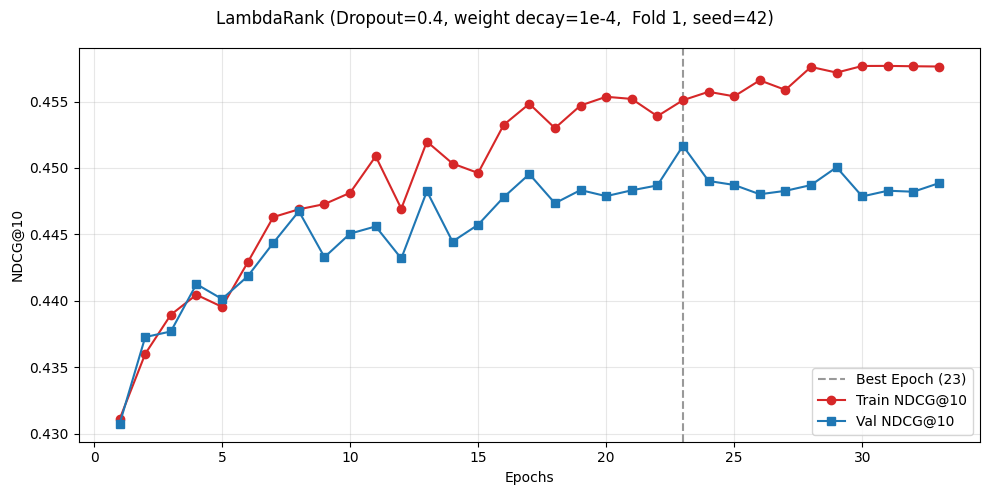

In [ ]:
plot_training_curves(train_ndcg_history,val_ndcg_history, "LambdaRank (Dropout=0.4, weight decay=1e-4,  Fold 1, seed=42)")

## Key Takeaways:
- The best validation(0.452) is a bit smaller compared to **dropout=0.3(0.455)**.
- The Curves started flattening out. The model stopped improving. We will see which is better by comparing the test data result.

## Results on Test Data

In [ ]:
test_ndcg = mean_ndcg(best_model, test_loader, k_list=K_LIST, device=DEVICE)

print("\nTest Set NDCG — Fold 1 (dropout = 0.3, seed=42)")
print(f"{'─'*30}")
for k in K_LIST:
    print(f"  NDCG@{k:<3}: {test_ndcg[k]:.4f}")



Test Set NDCG — Fold 1 (dropout = 0.3, seed=42)
──────────────────────────────
  NDCG@1  : 0.4328
  NDCG@3  : 0.4187
  NDCG@5  : 0.4242
  NDCG@10 : 0.4413


Test Set NDCG — Fold 1 (dropout = 0.3, seed=42)   
──────────────────────────────   
  NDCG@1  : 0.4436   
  NDCG@3  : 0.4253   
  NDCG@5  : 0.4315   
  NDCG@10 : 0.4478   
  ## Key Takeaways:
  - The performance at NDCG@10 is closer but at @1,@3 and @5 there is a good difference(~0.01) that 0.3 dropout performs better.

  ## Next Steps:
  - Sometimes overfitting happens because there are more parameters. So, i want to check the result if i change the structure from **(111->128->64->1) to (111->64->32->1)**

## Current Architecture: 111 -> 64 -> 32 -> 1
# Dropout = 0.2

In [ ]:
set_seed(42)
model = ScoringMLP(input_dim=111, hidden_dims=[64, 32], dropout=0.2).to(DEVICE)

best_model, last_model, train_ndcg_history, val_ndcg_history = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    mode="lambdarank",
    epochs=80,
    lr=0.001,
    k=10,
    weight_decay = 1e-4,
    patience=10,
    device=DEVICE,
    verbose=True,
)

Epoch 01/80 | Avg λ Norm: 4.6116 | Train NDCG@10: 0.4362 | Val NDCG@10: 0.4368  ← best
Epoch 02/80 | Avg λ Norm: 4.4560 | Train NDCG@10: 0.4401 | Val NDCG@10: 0.4398  ← best
Epoch 03/80 | Avg λ Norm: 4.4015 | Train NDCG@10: 0.4415 | Val NDCG@10: 0.4420  ← best
Epoch 04/80 | Avg λ Norm: 4.3850 | Train NDCG@10: 0.4450 | Val NDCG@10: 0.4433  ← best
Epoch 05/80 | Avg λ Norm: 4.3666 | Train NDCG@10: 0.4477 | Val NDCG@10: 0.4446  ← best
Epoch 06/80 | Avg λ Norm: 4.3451 | Train NDCG@10: 0.4469 | Val NDCG@10: 0.4436
Epoch 07/80 | Avg λ Norm: 4.3502 | Train NDCG@10: 0.4491 | Val NDCG@10: 0.4454  ← best
Epoch 08/80 | Avg λ Norm: 4.3118 | Train NDCG@10: 0.4532 | Val NDCG@10: 0.4483  ← best
Epoch 09/80 | Avg λ Norm: 4.2878 | Train NDCG@10: 0.4508 | Val NDCG@10: 0.4428
Epoch 10/80 | Avg λ Norm: 4.2983 | Train NDCG@10: 0.4527 | Val NDCG@10: 0.4453
Epoch 11/80 | Avg λ Norm: 4.2742 | Train NDCG@10: 0.4531 | Val NDCG@10: 0.4474
Epoch 12/80 | Avg λ Norm: 4.2701 | Train NDCG@10: 0.4555 | Val NDCG@10: 0.4

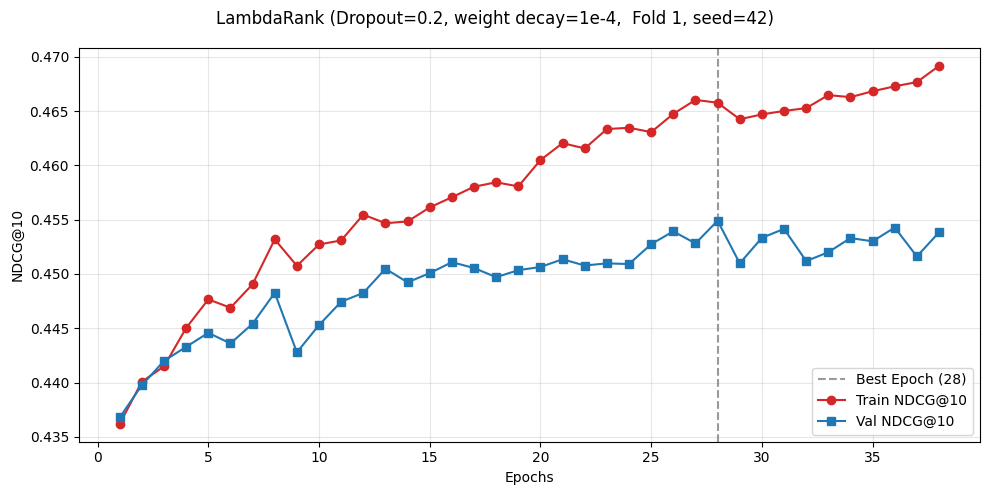

In [ ]:
plot_training_curves(train_ndcg_history,val_ndcg_history, "LambdaRank (Dropout=0.2, weight decay=1e-4,  Fold 1, seed=42)")

## Key Takeaways:
- I got a best validation of **0.455**. But i can see a gap increasing between the training and validation curve.

## Next steps:
- I want try increasing dropout.

## Results on Test Data

In [ ]:
test_ndcg = mean_ndcg(best_model, test_loader, k_list=K_LIST, device=DEVICE)

print("\nTest Set NDCG — Fold 1 (dropout = 0.2, seed=42)")
print(f"{'─'*30}")
for k in K_LIST:
    print(f"  NDCG@{k:<3}: {test_ndcg[k]:.4f}")



Test Set NDCG — Fold 1 (dropout = 0.2, seed=42)
──────────────────────────────
  NDCG@1  : 0.4308
  NDCG@3  : 0.4219
  NDCG@5  : 0.4277
  NDCG@10 : 0.4449


Test Set NDCG — Fold 1 (dropout = 0.3, seed=42)   
──────────────────────────────   
NDCG@1 : 0.4436   
NDCG@3 : 0.4253   
NDCG@5 : 0.4315   
NDCG@10 : 0.4478    
## Key Takeaways:
- The result is good enough but there is a bit difference between the current results and the best results we got.
- I will try increasing dropout.

## Increasing dropout(0.3)

In [ ]:
set_seed(42)
model = ScoringMLP(input_dim=111, hidden_dims=[64, 32], dropout=0.3).to(DEVICE)

best_model, last_model, train_ndcg_history, val_ndcg_history = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    mode="lambdarank",
    epochs=80,
    lr=0.001,
    k=10,
    weight_decay = 1e-4,
    patience=10,
    device=DEVICE,
    verbose=True,
)

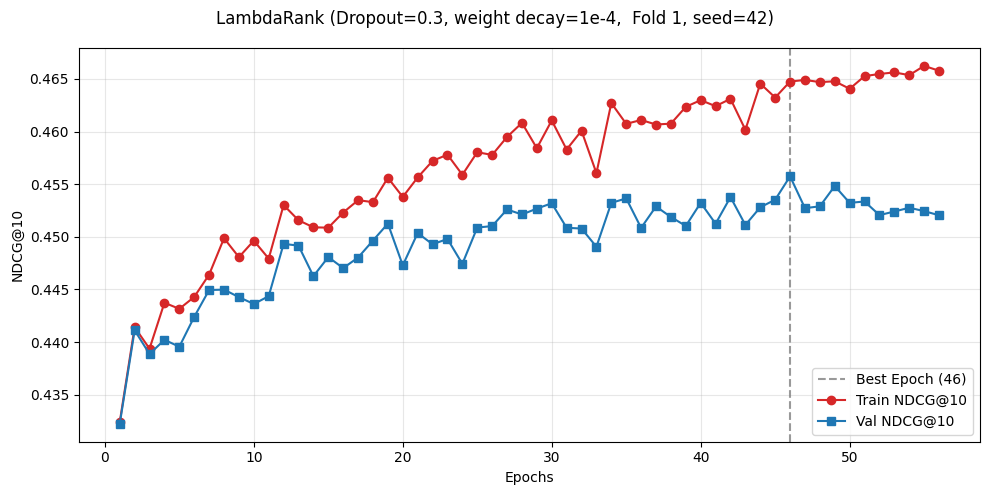

In [ ]:
plot_training_curves(train_ndcg_history,val_ndcg_history, "LambdaRank (Dropout=0.3, weight decay=1e-4,  Fold 1, seed=42)")

## Key takeaways:
- The gap between the curves is reduced but the best val is still same**(0.455)**.Let us see if the result is good on test data.

## Results on Test Data

In [ ]:
test_ndcg = mean_ndcg(best_model, test_loader, k_list=K_LIST, device=DEVICE)

print("\nTest Set NDCG — Fold 1 (dropout = 0.3, seed=42)")
print(f"{'─'*30}")
for k in K_LIST:
    print(f"  NDCG@{k:<3}: {test_ndcg[k]:.4f}")



Test Set NDCG — Fold 1 (dropout = 0.3, seed=42)
──────────────────────────────
  NDCG@1  : 0.4358
  NDCG@3  : 0.4222
  NDCG@5  : 0.4282
  NDCG@10 : 0.4450


Test Set NDCG — Fold 1 (dropout = 0.2, seed=42)   
──────────────────────────────   
  NDCG@1  : 0.4308   
  NDCG@3  : 0.4219   
  NDCG@5  : 0.4277   
  NDCG@10 : 0.4449   
## Key Takeaways:
- The results are almost close as when we used dropout=0.2.
- The training NDCG is going upto **0.465**.I want to see if the val ndcg reaches this if we further regularize it(use=0.35).

## Increasing Dropout(0.35)

In [ ]:
set_seed(42)
model = ScoringMLP(input_dim=111, hidden_dims=[64, 32], dropout=0.35).to(DEVICE)

best_model, last_model, train_ndcg_history, val_ndcg_history = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    mode="lambdarank",
    epochs=80,
    lr=0.001,
    k=10,
    weight_decay = 1e-4,
    patience=10,
    device=DEVICE,
    verbose=True,
)

Epoch 01/80 | Avg λ Norm: 4.7124 | Train NDCG@10: 0.4324 | Val NDCG@10: 0.4341  ← best
Epoch 02/80 | Avg λ Norm: 4.5303 | Train NDCG@10: 0.4376 | Val NDCG@10: 0.4385  ← best
Epoch 03/80 | Avg λ Norm: 4.5244 | Train NDCG@10: 0.4402 | Val NDCG@10: 0.4397  ← best
Epoch 04/80 | Avg λ Norm: 4.4871 | Train NDCG@10: 0.4409 | Val NDCG@10: 0.4374
Epoch 05/80 | Avg λ Norm: 4.4658 | Train NDCG@10: 0.4419 | Val NDCG@10: 0.4379
Epoch 06/80 | Avg λ Norm: 4.4556 | Train NDCG@10: 0.4411 | Val NDCG@10: 0.4373
Epoch 07/80 | Avg λ Norm: 4.4530 | Train NDCG@10: 0.4443 | Val NDCG@10: 0.4437  ← best
Epoch 08/80 | Avg λ Norm: 4.3915 | Train NDCG@10: 0.4460 | Val NDCG@10: 0.4437  ← best
Epoch 09/80 | Avg λ Norm: 4.4215 | Train NDCG@10: 0.4450 | Val NDCG@10: 0.4434
Epoch 10/80 | Avg λ Norm: 4.3981 | Train NDCG@10: 0.4478 | Val NDCG@10: 0.4427
Epoch 11/80 | Avg λ Norm: 4.4010 | Train NDCG@10: 0.4476 | Val NDCG@10: 0.4428
Epoch 12/80 | Avg λ Norm: 4.4015 | Train NDCG@10: 0.4490 | Val NDCG@10: 0.4455  ← best
Epoc

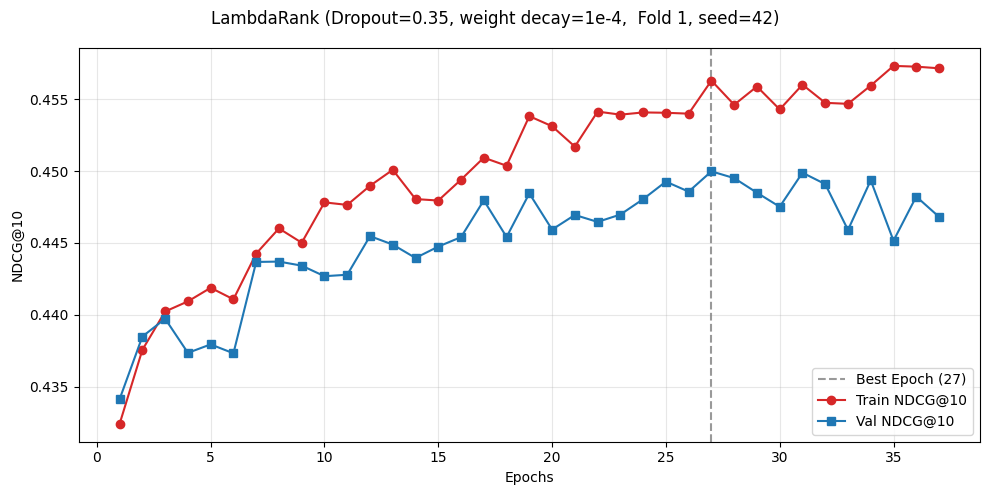

In [ ]:
plot_training_curves(train_ndcg_history,val_ndcg_history, "LambdaRank (Dropout=0.35, weight decay=1e-4,  Fold 1, seed=42)")

## Key Takeaways:
- Increasing dropout further made the performance worse. So, we need to choose between 0.2 and 0.3.

## Results on Test Data

In [ ]:
test_ndcg = mean_ndcg(best_model, test_loader, k_list=K_LIST, device=DEVICE)

print("\nTest Set NDCG — Fold 1 (dropout = 0.35, seed=42)")
print(f"{'─'*30}")
for k in K_LIST:
    print(f"  NDCG@{k:<3}: {test_ndcg[k]:.4f}")



Test Set NDCG — Fold 1 (dropout = 0.35, seed=42)
──────────────────────────────
  NDCG@1  : 0.4363
  NDCG@3  : 0.4210
  NDCG@5  : 0.4243
  NDCG@10 : 0.4394


## Key Takeaways:
- Test data performance is also worse as expected.

## Next steps:
- We need to choose the correct dropout and correct architecture. For this, I will perform a multiseed evaluation for these three models:
1. [111->128->64->1] dropout=0.2
2. [111->128->64->1] dropout=0.3
3. [111->64->32->1] dropout=0.3

## Step 7 · Multiseed Evaluation

In [ ]:
hidden = [[128,64],[128,64],[64,32]]
dropouts = [0.2,0.3,0.3]
for i in range(3):
  lambdarank_results = cross_fold_eval(
      model_fn=lambda: ScoringMLP(input_dim=111, hidden_dims=hidden[i], dropout=dropouts[i]),
      mode="lambdarank",
      base_path=DATA_PATH,
      folds=[1],
      data_loader_fn=load_fold,
      seeds=SEEDS,
      k_list=K_LIST,
      batch_size=4,
      device=DEVICE,
      epochs=50,
      lr = 0.001,
      weight_decay = 1e-4,
      patience=10,
  )



═══════════════════════════════════════════════════════
  FOLD 1 / 1
═══════════════════════════════════════════════════════
  [Fold 1] Loading train split...


  [Fold 1] Loading val split...


  [Fold 1] Loading test split...


  Fold 1: 6000 train | 2000 val | 2000 test queries
  Features: 111 (136 total − 25 dropped)
  Normalization: Per-query z-score
  NDCG@1  : 0.4362 ± 0.0030
  NDCG@3  : 0.4261 ± 0.0017
  NDCG@5  : 0.4320 ± 0.0008
  NDCG@10 : 0.4478 ± 0.0001

═══════════════════════════════════════════════════════
  OVERALL RESULTS (LAMBDARANK)
═══════════════════════════════════════════════════════
  NDCG@1  : 0.4362 ± 0.0030
  NDCG@3  : 0.4261 ± 0.0017
  NDCG@5  : 0.4320 ± 0.0008
  NDCG@10 : 0.4478 ± 0.0001
═══════════════════════════════════════════════════════


═══════════════════════════════════════════════════════
  FOLD 1 / 1
═══════════════════════════════════════════════════════
  [Fold 1] Loading train split...


  [Fold 1] Loading val split...


  [Fold 1] Loading test split...


  Fold 1: 6000 train | 2000 val | 2000 test queries
  Features: 111 (136 total − 25 dropped)
  Normalization: Per-query z-score
  NDCG@1  : 0.4399 ± 0.0041
  NDCG@3  : 0.4264 ± 0.0010
  NDCG@5  : 0.4304 ± 0.0008
  NDCG@10 : 0.4456 ± 0.0016

═══════════════════════════════════════════════════════
  OVERALL RESULTS (LAMBDARANK)
═══════════════════════════════════════════════════════
  NDCG@1  : 0.4399 ± 0.0041
  NDCG@3  : 0.4264 ± 0.0010
  NDCG@5  : 0.4304 ± 0.0008
  NDCG@10 : 0.4456 ± 0.0016
═══════════════════════════════════════════════════════


═══════════════════════════════════════════════════════
  FOLD 1 / 1
═══════════════════════════════════════════════════════
  [Fold 1] Loading train split...


  [Fold 1] Loading val split...


  [Fold 1] Loading test split...


  Fold 1: 6000 train | 2000 val | 2000 test queries
  Features: 111 (136 total − 25 dropped)
  Normalization: Per-query z-score
  NDCG@1  : 0.4362 ± 0.0019
  NDCG@3  : 0.4253 ± 0.0025
  NDCG@5  : 0.4292 ± 0.0010
  NDCG@10 : 0.4448 ± 0.0006

═══════════════════════════════════════════════════════
  OVERALL RESULTS (LAMBDARANK)
═══════════════════════════════════════════════════════
  NDCG@1  : 0.4362 ± 0.0019
  NDCG@3  : 0.4253 ± 0.0025
  NDCG@5  : 0.4292 ± 0.0010
  NDCG@10 : 0.4448 ± 0.0006
═══════════════════════════════════════════════════════



|Metric|[128,64], 0.2|[128,64], 0.3|[64,32], 0.3|  
|------|-------|-----|-------|  
|NDCG@1|0.436 ± 0.003|0.440 ± 0.004|0.436 ± 0.002
|NDCG@3|0.426 ± 0.002|0.426 ± 0.001|0.425 ± 0.003
|NDCG@5|0.432 ± 0.001|0.430 ± 0.001|0.429 ± 0.001
|NDCG@10|0.448 ± 0.000|0.446 ± 0.002|0.445 ± 0.001


## Key Takeaways:
- The architecture with less parameters performed the worst. We will stick to the original network we had.
- Comparing the result with Dropout = 0.2 and 0.3. At k>=5, NDCG@K is better in the first one with low std. At k < 5, They are not Distuinguishable. At k=1, the mean is higher in the second case but std is also higher.
- At k==10, the mean is lower and std is higher for 0.3 dropout.
- Using dropout=0.2, is better than 0.3 for futher comparisions.

## Step 8 · 5-Fold Evaluation (Standard MSLR Folds)

We are using the exact 5 test splits provided by the dataset authors, rather than
shuffling and making our own cross-validation splits. This makes sure our results
can be fairly compared to published papers.

Each fold is trained across **2 random seeds** and results are reported as **Mean ± Std**.


In [ ]:
def print_results_table(results, title, k_list=(1, 3, 5, 10)):
    """Pretty-print a cross_fold_eval or train_multiseed results dict."""
    summary = results.get("overall", results.get("summary", {}))
    print(f"\n{'═'*45}")
    print(f"  {title}")
    print(f"{'═'*45}")
    print(f"{'Metric':<10}  {'Mean':>8}  {'Std':>8}")
    print(f"{'─'*45}")
    for k in k_list:
        if k in summary:
            m, s = summary[k]["mean"], summary[k]["std"]
            print(f"NDCG@{k:<5}  {m:>8.4f}  {s:>8.4f}")
    print(f"{'═'*45}")


In [ ]:
SEEDS = [42,123]
lambdarank_results = cross_fold_eval(
    model_fn=lambda: ScoringMLP(input_dim=111, hidden_dims=[128, 64], dropout=0.2),
    mode="lambdarank",
    base_path=DATA_PATH,
    folds=(1, 2, 3, 4, 5),
    seeds=SEEDS,
    data_loader_fn=load_fold,
    k_list=K_LIST,
    batch_size=4,
    device=DEVICE,
    epochs=50,
    lr = 0.001,
    weight_decay = 1e-4,
    patience=10,
)

print_results_table(lambdarank_results, "LAMBDARANK — 5-Fold Results")



═══════════════════════════════════════════════════════
  FOLD 1 / 5
═══════════════════════════════════════════════════════
  [Fold 1] Loading train split...


  [Fold 1] Loading val split...


  [Fold 1] Loading test split...


  Fold 1: 6000 train | 2000 val | 2000 test queries
  Features: 111 (136 total − 25 dropped)
  Normalization: Per-query z-score
  NDCG@1  : 0.4341 ± 0.0006
  NDCG@3  : 0.4272 ± 0.0009
  NDCG@5  : 0.4316 ± 0.0008
  NDCG@10 : 0.4478 ± 0.0001

═══════════════════════════════════════════════════════
  FOLD 2 / 5
═══════════════════════════════════════════════════════
  [Fold 2] Loading train split...


  [Fold 2] Loading val split...


...

  [Fold 4] Loading test split...


  Fold 4: 6000 train | 2000 val | 2000 test queries
  Features: 111 (136 total − 25 dropped)
  Normalization: Per-query z-score
  NDCG@1  : 0.4514 ± 0.0043
  NDCG@3  : 0.4347 ± 0.0000
  NDCG@5  : 0.4411 ± 0.0003
  NDCG@10 : 0.4564 ± 0.0005

═══════════════════════════════════════════════════════
  FOLD 5 / 5
═══════════════════════════════════════════════════════
  [Fold 5] Loading train split...


  [Fold 5] Loading val split...


  [Fold 5] Loading test split...


  Fold 5: 6000 train | 2000 val | 2000 test queries
  Features: 111 (136 total − 25 dropped)
  Normalization: Per-query z-score
  NDCG@1  : 0.4463 ± 0.0022
  NDCG@3  : 0.4311 ± 0.0016
  NDCG@5  : 0.4383 ± 0.0009
  NDCG@10 : 0.4565 ± 0.0013

═══════════════════════════════════════════════════════
  OVERALL RESULTS (LAMBDARANK)
═══════════════════════════════════════════════════════
  NDCG@1  : 0.4455 ± 0.0064
  NDCG@3  : 0.4299 ± 0.0029
  NDCG@5  : 0.4354 ± 0.0038
  NDCG@10 : 0.4511 ± 0.0048
═══════════════════════════════════════════════════════


═════════════════════════════════════════════
  LAMBDARANK — 5-Fold Results
═════════════════════════════════════════════
Metric          Mean       Std
─────────────────────────────────────────────
NDCG@1        0.4455    0.0064
NDCG@3        0.4299    0.0029
NDCG@5        0.4354    0.0038
NDCG@10       0.4511    0.0048
═════════════════════════════════════════════




## Results — 5-Fold Cross-Validation
| Metric | Mean | Std |
|---|---|---|
| NDCG@1 | 0.446 | 0.006 |
| NDCG@3 | 0.430 | 0.003 |
| NDCG@5 | 0.435 | 0.004 |
| NDCG@10 | 0.451 | 0.005 |
- We got an NDCG@10 of **0.451** this is the best result we got till now on MSLR 10k dataset.
- The Score at NDCG@1 is higher because lambdarank gives more preference to the pairs that give big ndcg difference if we swap them.
- The std is very low. The models is stable across different splits of data.

## Next steps:
- I will do an ablation study by changing the depth of the neural network. I will fold-3 for this task because it has the close results to the mean score across all folds.

## · Save Results

In [ ]:
import json

os.makedirs("/content/ltr_results", exist_ok=True)

def to_serialisable(obj):
    if isinstance(obj, dict):
        return {k: to_serialisable(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [to_serialisable(v) for v in obj]
    if isinstance(obj, (np.floating, float)):
        return float(obj)
    if isinstance(obj, (np.integer, int)):
        return int(obj)
    return obj

with open("/content/ltr_results/lambdarank_results.json", "w") as f:
    json.dump(to_serialisable(lambdarank_results), f, indent=2)

print("Results saved to /content/ltr_results/lambdarank_results.json")


Results saved to /content/ltr_results/lambdarank_results.json


## Step 9 · Ablation Study — Architecture Comparison

We lock the data to **Fold 3** and swap out the underlying network architecture,
keeping everything else identical. This isolates the impact of depth and
dropout regularization on NDCG@10.

| Config | Hidden dims | Dropout |
|---|---|---|
| Linear | `[]` | 0.0 |
| Deep | `[128, 64, 32]` | 0.2 |


In [5]:
# ── Lock data to Fold 1 ───────────────────────────────────────────────────────
train_loader_f1, val_loader_f1, test_loader_f1 = load_fold(
    base_path=DATA_PATH, fold_num=3, batch_size=4
)

# ── Ablation configurations ───────────────────────────────────────────────────
ablation_configs = {
    "Linear":      {"hidden_dims": [],              "dropout": 0.0},
    "Deep":        {"hidden_dims": [128, 64, 32],"dropout": 0.2},
}

ablation_results = {}

for arch_name, cfg in ablation_configs.items():
    print(f"\nTraining {arch_name} ...")
    result = train_multiseed(
        model_fn=lambda h=cfg["hidden_dims"], d=cfg["dropout"]: ScoringMLP(111, h, d),
        train_loader=train_loader_f1,
        val_loader=val_loader_f1,
        test_loader=test_loader_f1,
        mode="lambdarank",
        seeds=SEEDS,
        k_list=K_LIST,
        device=DEVICE,
        epochs=50,
        lr = 0.001,
        weight_decay=1e-4,
        patience=10,
        verbose=False,
    )
    ablation_results[arch_name] = result["summary"]
    ndcg10 = result["summary"][10]
    print(f"  NDCG@10: {ndcg10['mean']:.4f} ± {ndcg10['std']:.4f}")


  [Fold 3] Loading train split...


  [Fold 3] Loading val split...


  [Fold 3] Loading test split...


  Fold 3: 6000 train | 2000 val | 2000 test queries
  Features: 111 (136 total − 25 dropped)
  Normalization: Per-query z-score

Training Linear ...
  NDCG@10: 0.4204 ± 0.0001

Training Deep ...
  NDCG@10: 0.4475 ± 0.0009


In [16]:
# ── Ablation results table ────────────────────────────────────────────────────
print(f"\n{'═'*75}")
print(f"  ABLATION STUDY — NDCG@10 (Fold 1, Mean ± Std over 3 seeds)")
print(f"{'═'*75}")
print(f"{'Architecture':<10}  {'NDCG@1':>13}  {'NDCG@3':>12}  {'NDCG@5':>12}  {'NDCG@10':>12}")
print(f"{'─'*75}")
for arch_name, summary in ablation_results.items():
    row = "  ".join(
        f"{summary[k]['mean']:>6.3f}±{summary[k]['std']:.3f}" for k in [1, 3, 5, 10]
    )
    print(f"{arch_name:<15}  {row}")
print(f"{'═'*75}")



═══════════════════════════════════════════════════════════════════════════
  ABLATION STUDY — NDCG@10 (Fold 1, Mean ± Std over 3 seeds)
═══════════════════════════════════════════════════════════════════════════
Architecture         NDCG@1        NDCG@3        NDCG@5       NDCG@10
───────────────────────────────────────────────────────────────────────────
Linear            0.409±0.001   0.400±0.001   0.405±0.000   0.420±0.000
Deep              0.449±0.009   0.427±0.002   0.431±0.002   0.447±0.001
═══════════════════════════════════════════════════════════════════════════


## Fold3 Results:   
NDCG@1  : 0.4485 ± 0.0008    
NDCG@3  : 0.4278 ± 0.0011   
NDCG@5  : 0.4339 ± 0.0003   
NDCG@10 : 0.4501 ± 0.0007   

## Results — Ablation Study

- A simple linear model performed worst. It is not enough to capture the learning signal.
- A Deep Network is performing the same as our baseline model. This says that increasing the complexity doesn't increase the result. It can capture the signal until reaches the ceiling only.

## Conclusion

- LambdaRank performed better than RankNet especially at k=1, because lambdarank directly optimizes the Evaluation metric(NDCG) we are using.
- Using per-Query Normalization is very important.
- If we use weight decay, Using Adamw instead of Adam optimizer is very important.


## Checking if weight decay affects the model

Till now i have used weight decay, I will train and test the model without decay now.

In [18]:
set_seed(42)
model = ScoringMLP(input_dim=111, hidden_dims=[128, 64], dropout=0.3).to(DEVICE)

best_model, last_model, train_ndcg_history, val_ndcg_history = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    mode="lambdarank",
    epochs=80,
    lr=0.001,
    k=10,
    patience=10,
    device=DEVICE,
    verbose=True,
)

Epoch 01/80 | Avg λ Norm: 4.6182 | Train NDCG@10: 0.4284 | Val NDCG@10: 0.4279  ← best
Epoch 02/80 | Avg λ Norm: 4.4687 | Train NDCG@10: 0.4368 | Val NDCG@10: 0.4378  ← best
Epoch 03/80 | Avg λ Norm: 4.4271 | Train NDCG@10: 0.4408 | Val NDCG@10: 0.4384  ← best
Epoch 04/80 | Avg λ Norm: 4.4085 | Train NDCG@10: 0.4453 | Val NDCG@10: 0.4415  ← best
Epoch 05/80 | Avg λ Norm: 4.3891 | Train NDCG@10: 0.4487 | Val NDCG@10: 0.4468  ← best
Epoch 06/80 | Avg λ Norm: 4.3784 | Train NDCG@10: 0.4451 | Val NDCG@10: 0.4416
Epoch 07/80 | Avg λ Norm: 4.3464 | Train NDCG@10: 0.4489 | Val NDCG@10: 0.4480  ← best
Epoch 08/80 | Avg λ Norm: 4.3578 | Train NDCG@10: 0.4501 | Val NDCG@10: 0.4484  ← best
Epoch 09/80 | Avg λ Norm: 4.3459 | Train NDCG@10: 0.4508 | Val NDCG@10: 0.4451
Epoch 10/80 | Avg λ Norm: 4.3051 | Train NDCG@10: 0.4530 | Val NDCG@10: 0.4499  ← best
Epoch 11/80 | Avg λ Norm: 4.3445 | Train NDCG@10: 0.4519 | Val NDCG@10: 0.4469
Epoch 12/80 | Avg λ Norm: 4.3243 | Train NDCG@10: 0.4540 | Val NDCG

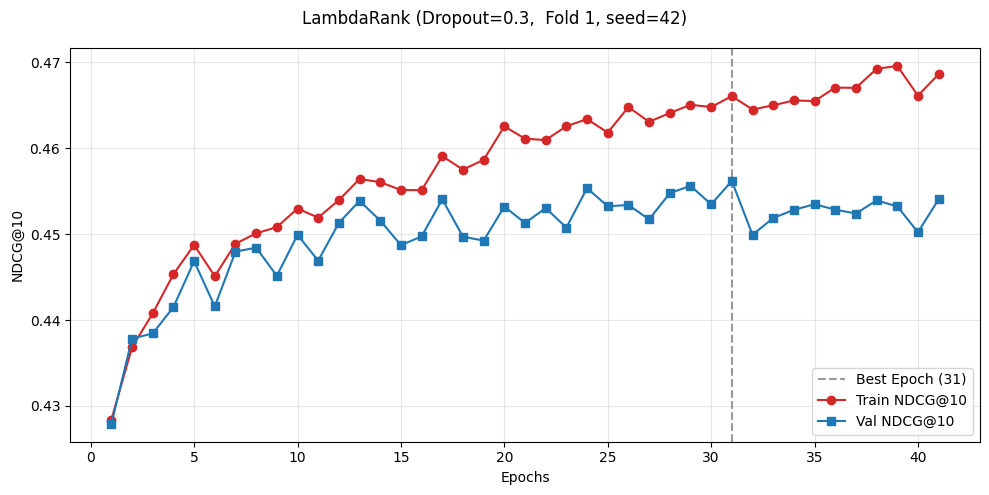

In [23]:
plot_training_curves(train_ndcg_history,val_ndcg_history, "LambdaRank (Dropout=0.3,  Fold 1, seed=42)")

- The performance is similar to the performance when we used weight decay.
- Even the training speed is also same.

In [20]:
test_ndcg = mean_ndcg(best_model, test_loader, k_list=K_LIST, device=DEVICE)

print("\nTest Set NDCG — Fold 1 (dropout = 0.3, seed=42)")
print(f"{'─'*30}")
for k in K_LIST:
    print(f"  NDCG@{k:<3}: {test_ndcg[k]:.3f}")



Test Set NDCG — Fold 1 (dropout = 0.3, seed=42)
──────────────────────────────
  NDCG@1  : 0.438
  NDCG@3  : 0.424
  NDCG@5  : 0.431
  NDCG@10 : 0.448


Test Set NDCG — Fold 1 (dropout = 0.3, weight_decay=1e-4, seed=42)   
──────────────────────────────   
  NDCG@1  : 0.4436   
  NDCG@3  : 0.4253  
  NDCG@5  : 0.4315   
  NDCG@10 : 0.4478   

  ## Key Takeaway:
  - The Result is same even if we don't use weight decay.
  - Therefore, Weight decay has no effect here.